In [3]:
#1 Import des bibliothèques

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.20.0


In [5]:
#2 Chargement et pretraitement de MNIST

In [6]:
# Chargement automatique
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalisation [0,1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Ajout du canal (28,28) -> (28,28,1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("Forme entraînement :", X_train.shape)  # (60000, 28, 28, 1)
print("Forme test         :", X_test.shape)   # (10000, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 27s 2us/step
Forme entraînement : (60000, 28, 28, 1)
Forme test         : (10000, 28, 28, 1)


In [10]:
#3 Construction du modèle CNN

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2, 2)),
    
    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Classifieur
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

C:\Users\gauth\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#4 Compilation

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
#5 Entraînement

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,   # 10% des données d'entraînement pour validation
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8493 - loss: 0.4813 - val_accuracy: 0.9862 - val_loss: 0.0546
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9738 - loss: 0.0884 - val_accuracy: 0.9885 - val_loss: 0.0410
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9801 - loss: 0.0651 - val_accuracy: 0.9905 - val_loss: 0.0357
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9841 - loss: 0.0493 - val_accuracy: 0.9912 - val_loss: 0.0327
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9857 - loss: 0.0455 - val_accuracy: 0.9913 - val_loss: 0.0366
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9893 - loss: 0.0361 - val_accuracy: 0.9912 - val_loss: 0.0325
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9910 - loss: 0.0293 - val_accuracy: 0.9918 - val_loss: 0.0328
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9924 - loss: 0.0243 - 

In [17]:
#6 Evaluation sur le jeu de test 

In [18]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Précision sur le test : {test_acc*100:.2f}%")

Précision sur le test : 99.29%


In [19]:
#7 Courbes d'apprentissage

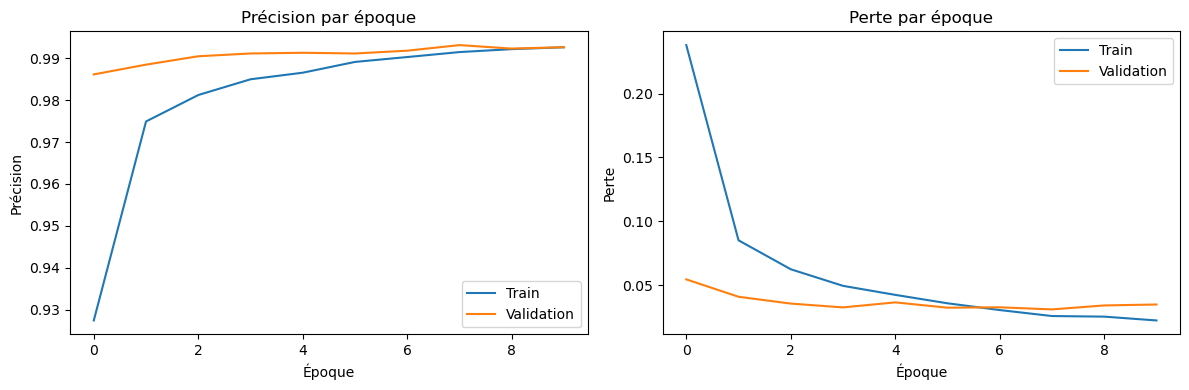

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Précision par époque')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Perte par époque')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
#8 Affichage de prédictions aléatoires

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


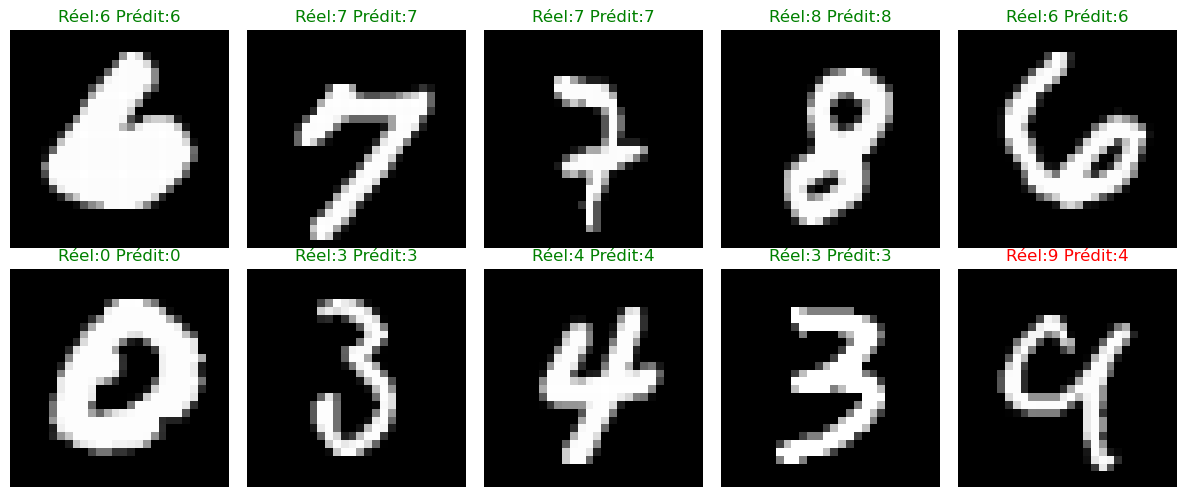

In [22]:
indices = np.random.choice(len(X_test), 10)
images = X_test[indices]
true_labels = y_test[indices]
predictions = np.argmax(model.predict(images), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predictions[i] == true_labels[i] else 'red'
    ax.set_title(f"Réel:{true_labels[i]} Prédit:{predictions[i]}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [23]:
#9 Sauvegarde du modèle

In [24]:
# Exporter le modèle en format H5
model.save('mnist_cnn_model.h5')
print("Modèle sauvegardé : mnist_cnn_model.h5")

Modèle sauvegardé : mnist_cnn_model.h5
